In [1]:
import os
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
run_name = "ch12"

data_dir = Path("data") / "ch12"
tsv = data_dir / "training.tsv"

In [3]:
df = pd.read_csv(tsv, sep='\t')
df = df.sort_values(by='step', ascending=True)
df = df.drop_duplicates(subset=['step', 'split'], keep='last')

train_df = df.loc[df['split'] == 'train', :]
eval_df = df.loc[df['split'] == 'eval', :]

df.nsmallest(10, 'loss')

,step,epoch,split,loss,learning_rate,created_at
99,4300,139,train,0.007,0.000274,2025-09-30T13:56:38%:z
98,4250,138,train,0.009,0.000275,2025-09-30T13:53:47%:z
100,4350,141,train,0.009,0.000273,2025-09-30T13:59:26%:z
96,4150,134,train,0.010,0.000276,2025-09-30T13:48:11%:z
97,4200,136,train,0.010,0.000275,2025-09-30T13:50:59%:z
101,4400,142,train,0.013,0.000272,2025-09-30T14:02:16%:z
95,4100,133,train,0.014,0.000277,2025-09-30T13:45:21%:z
117,5100,165,train,0.015,0.000262,2025-09-30T14:41:45%:z
118,5150,167,train,0.017,0.000261,2025-09-30T14:44:33%:z
94,4050,131,train,0.018,0.000277,2025-09-30T13:42:33%:z


In [4]:
train_df.tail(10)

,step,epoch,split,loss,learning_rate,created_at
111,4850,157,train,0.112,0.000266,2025-09-30T14:27:37%:z
112,4900,159,train,0.098,0.000265,2025-09-30T14:30:25%:z
113,4950,160,train,0.068,0.000264,2025-09-30T14:33:15%:z
114,5000,162,train,0.040,0.000264,2025-09-30T14:36:03%:z
116,5050,163,train,0.025,0.000263,2025-09-30T14:38:57%:z
117,5100,165,train,0.015,0.000262,2025-09-30T14:41:45%:z
118,5150,167,train,0.017,0.000261,2025-09-30T14:44:33%:z
119,5200,168,train,0.044,0.000260,2025-09-30T14:47:24%:z
120,5250,170,train,0.029,0.000259,2025-09-30T14:50:12%:z
121,5300,171,train,0.025,0.000259,2025-09-30T14:53:00%:z


In [5]:
eval_df.tail(10)

,step,epoch,split,loss,learning_rate,created_at
10,500,17,eval,7.150,NaN,2025-09-30T09:03:00%:z
21,1000,33,eval,8.389,NaN,2025-09-30T09:31:37%:z
32,1500,49,eval,10.494,NaN,2025-09-30T10:00:14%:z
43,2000,65,eval,11.816,NaN,2025-09-30T10:28:34%:z
60,2500,81,eval,12.692,NaN,2025-09-30T12:14:59%:z
71,3000,97,eval,13.342,NaN,2025-09-30T12:43:12%:z
82,3500,113,eval,13.377,NaN,2025-09-30T13:11:29%:z
93,4000,130,eval,14.067,NaN,2025-09-30T13:39:42%:z
104,4500,146,eval,14.106,NaN,2025-09-30T14:07:54%:z
115,5000,162,eval,14.233,NaN,2025-09-30T14:36:05%:z


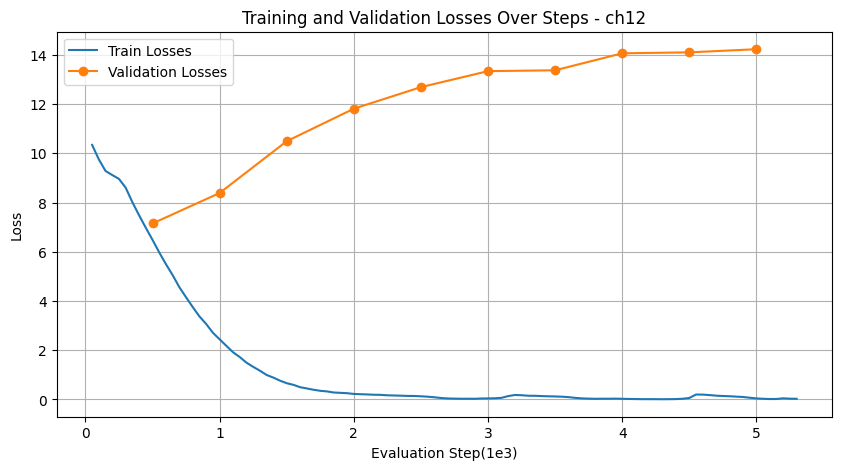

In [6]:
plt.figure(figsize=(10, 5))
plt.plot(train_df['step']/1e3, train_df['loss'], label="Train Losses")
plt.plot(eval_df['step']/1e3, eval_df['loss'], label="Validation Losses", marker='o')
plt.xlabel("Evaluation Step(1e3)")
plt.ylabel("Loss")
#plt.xlim(0, max(1e6, df["step"].max()))

plt.title(f"Training and Validation Losses Over Steps - {run_name}")
plt.legend()
plt.grid()

#plt.show()
plt.savefig(data_dir / "training.pdf")

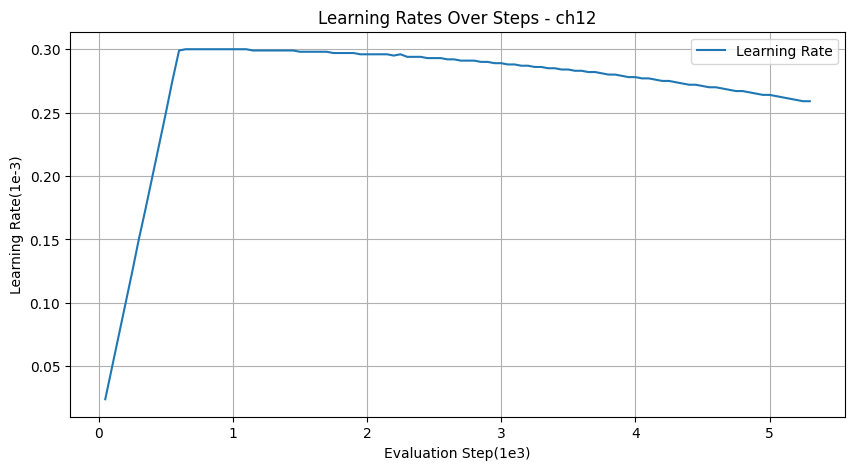

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(train_df['step']/1e3, train_df['learning_rate']*1e3, label="Learning Rate")
plt.xlabel("Evaluation Step(1e3)")
plt.ylabel("Learning Rate(1e-3)")
plt.title(f"Learning Rates Over Steps - {run_name}")
plt.legend()
plt.grid()
#plt.xlim(0, max(1e6, df["step"].max()))
#plt.show()
plt.savefig(data_dir / "learning_rate.pdf")